# Homework10

Exercises with text processing and NLP modeling

## Goals

- Understand similarities and differences between the processes of working with text, images and tabular data
- Practice with different methods of encoding and modeling text data
- See different methods for extracting information or patterns from text datasets

### Setup

Run the following 2 cells to import all necessary libraries and helpers for this homework.

In [1]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/text_utils.py

In [2]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from data_utils import display_silhouette_plots, object_from_json_url
from text_utils import get_top_words

You can tell it's gonna be a good homework from the number of imports.
# 🙃

## Cheat Sheet

There are lots of conversions in this homework between lists, strings, vectors, scores, etc...

This list can help as a quick reference for the names of the functions and what they expect as input, and produce as output.

These all operate on lists of _something_ and return lists of _something else_. But, here, let's just focus on the _type_ of the elements that go in these lists. Most of them will work on single elements, but not all.

`TFIDF.fit_transform(string)` / `TFIDF.transform(string)` : string -> sparse vector

`TFIDF.inverse_transform(vector)` : sparse vector -> list of words (NOT a string)

`TFIDF.get_feature_names_out()` : None -> list of words (vocab of dataset)

`TFIDF.get_feature_names_out()[idx]` : int (column index / word id) -> word

`vector.toarray()` : vector -> regular array

`get_top_words(vector, vocab, n_words=N)` : vector + list of all words + int -> list of top-N words in vector

`argsort(metric)` : list of floats -> list of int indexes

For example:

To get the words in a sentence ordered by importance (most important first), we have to turn a string into a vector, then the vector into a regular list of scores, then the list into indexes, and, finally, fetch words from our vocab list using these indexes.

```py
sentence = "a sentence goes here"
num_words = len(sentence.split(" "))
sentence_vct = TFIDF.transform([sentence])
sentence_vct_list = sentence_vct.toarray()
idx_by_importance = argsort(sentence_vct_list, reverse=True)[:num_words]
TFIDF.get_feature_names_out()[idx_by_importance]
```

For this particular example we could've used the `get_top_words()` function to get words ordered by importance:

```py
sentence = "a sentence goes here"
num_words = len(sentence.split(" "))

get_top_words(
  TFIDF.transform([sentence]),
  TFIDF.get_feature_names_out(),
  n_words=num_words
)
```

## Have protein, need seasoning

Let's create a model to help us season our foods. In the end, what we want is a model that receives a short list of ingredients and returns a list of seasonings or complementary ingredients for our original ingredients list.

In order to do that we need a dataset of recipes. We'll load that into a text dataset where each recipe is a document and the ingredients are our document *tokens*.

Let's take a look at the recipe dataset and become familiar with the data and how it's organized.

We'll load our recipes and do a bit of exploratory data analysis to look for patterns first to see if this kind of modeling makes any sense.

### Load Data

Here's our dataset. Let's load it into an object for inspection:

In [3]:
DATA_PATH = "https://raw.githubusercontent.com/PSAM-5020-2026S-A/5020-utils/refs/heads/main/datasets/text/recipes/recipes_min16.json"
recipes_obj = object_from_json_url(DATA_PATH)

### Look at Data

How's the data organized?

How many recipes do we have?

Do all recipes have the same number of ingredients?

Anything else stand out about the data?

In [4]:
# TODO: Look at Data here
print(type(recipes_obj))
print(recipes_obj[0])

# TODO: How many recipes
print(f"\nNumber of recipes: {len(recipes_obj)}")

# TODO: How many ingredients do the shortest and longest recipes have?
ingredient_counts = [len(r["ingredients"]) for r in recipes_obj]
print(f"Shortest recipe: {min(ingredient_counts)} ingredients")
print(f"Longest recipe: {max(ingredient_counts)} ingredients")

<class 'list'>
{'id': 18009, 'ingredients': ['raisins', 'baking powder', 'egg', 'sugar', 'milk', 'flour']}

Number of recipes: 5015
Shortest recipe: 5 ingredients
Longest recipe: 27 ingredients


### Create Input Features

Our dataset doesn't really have to be a `DataFrame` here. It can, but it doesn't have to be.

Each recipe right now is described as a list of ingredients, but what we really want is a list of *sentences*, where each *sentence* is a Python `string` with all of the ingredients for a given recipe.

Instead of:<br>```["salt", "baking soda", "water", "mushroom"]```,

we want:<br>```"salt baking soda water mushroom"```

The `join()` function might help.

Another thing to consider is wether we want to do anything special about multi-word ingredients, like *baking soda*.

Do we want to let our vectorizer split that into two tokens, or do we want to guarantee that *baking* and *soda* always stay together? 

In [5]:
# TODO: turn list of objects into list of strings
# Replace spaces in multi-word ingredients with underscores so they stay as one token
recipes = [
    " ".join(ingredient.replace(" ", "_") for ingredient in r["ingredients"])
    for r in recipes_obj
]

# Lemme see a few
for r in recipes[:3]:
    print(r)

raisins baking_powder egg sugar milk flour
parmesan_cheese salt cornmeal black_pepper sausage olive_oil leeks water
salt corn_starch butter lemon_juice baking_powder heavy_cream peaches sugar flour


### Encode Data

The fun part.

Let's vectorize our list of ingredient strings into a sparse document matrix using `CountVectorizer` or `TfidfVectorizer`.

The resulting matrix will have one row for each recipe, and the columns will encode the ingredients.

In [8]:
# TODO: Vectorize ingredients from our recipe list
TFIDF = TfidfVectorizer()
recipes_vct = TFIDF.fit_transform(recipes)

# TODO: How many words are in our vocabulary?
vocab = TFIDF.get_feature_names_out()
print(f"Vocab size: {len(vocab)} unique ingredients")
print(f"Matrix shape: {recipes_vct.shape} (recipes x ingredients)")

Vocab size: 520 unique ingredients
Matrix shape: (5015, 520) (recipes x ingredients)


### Cluster Data

Now that we have our recipes/documents vectorized we can study them a little bit, and look for patterns.

What happens if we cluster our recipes ? What do the cluster centers represent ?

When might this be useful ?

In [13]:
# TODO: cluster recipes
# There 5000 recipes, so 8 feels inuitively good enuf to me
NUM_CLUSTERS = 8

kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init="auto")
recipe_clusters = kmeans.fit_predict(recipes_vct)

print(f"Cluster labels of first 10: {recipe_clusters[:10]}")
print(f"Recipes per cluster:")
for i in range(NUM_CLUSTERS):
    print(f"  Cluster {i}: {(recipe_clusters == i).sum()} recipes")

Cluster labels of first 10: [7 5 7 6 4 5 3 7 1 0]
Recipes per cluster:
  Cluster 0: 396 recipes
  Cluster 1: 883 recipes
  Cluster 2: 685 recipes
  Cluster 3: 484 recipes
  Cluster 4: 894 recipes
  Cluster 5: 492 recipes
  Cluster 6: 618 recipes
  Cluster 7: 563 recipes


### Cluster Centers

Use the `get_top_words()` function to decode the `cluster_centers` back into ingredients.

In [17]:
# TODO: Look at cluster centers
import numpy as np

for i, center in enumerate(kmeans.cluster_centers_):
    top = get_top_words(np.array([center]), vocab, n_words=8)
    print(f"Cluster {i}: {top}")

Cluster 0: ['thyme', 'onion', 'rice', 'greenpepper', 'bay', 'garlic', 'celery', 'tomatoes']
Cluster 1: ['salt', 'butter', 'egg', 'pepper', 'potatoes', 'onion', 'black_pepper', 'water']
Cluster 2: ['olive_oil', 'garlic', 'tomatoes', 'wine', 'parsley', 'salt', 'basil', 'black_pepper']
Cluster 3: ['tortilla', 'sour_cream', 'cheddar_cheese', 'salsa', 'cilantro', 'chili', 'onion', 'black_bean']
Cluster 4: ['cilantro', 'chili', 'onion', 'garlic', 'cumin', 'salt', 'ginger', 'lime_juice']
Cluster 5: ['parmesan_cheese', 'olive_oil', 'garlic', 'basil', 'salt', 'black_pepper', 'butter', 'mozzarella_cheese']
Cluster 6: ['soy_sauce', 'sesame_oil', 'ginger', 'sugar', 'garlic', 'vinegar', 'rice', 'corn_starch']
Cluster 7: ['flour', 'egg', 'sugar', 'butter', 'milk', 'baking_powder', 'vanilla', 'salt']


### Interpretation

What do these cluster centers represent? Is there anything interesting about recipe cluster centers?

<span style="color:hotpink">
Each cluster center is basically the average recipe for that group. Like if you were to blend all the recipes in a cluster together, what ingredients would show up most? That would be the center. The results are kind wild because I never told the model anything about cuisines, but it just... found them anyway. Cluster 7 is clearly baking. Cluster 6 is East Asian. Cluster 3 is Tex-Mex? It figured that out purely from ingredient co-occurrence patterns. So a cluster center is kind of like the essence of a food culture, distilled into a handful of ingredients. Pretty cool that it works.
<span>

### Plot Clusters

Let's plot our clusters to see if we have to adjust any of the clustering parameters.

Since we can't plot in $500$ dimensions, we should use `TruncatedSVD` to look at our clusters in $2D$ and $3D$.

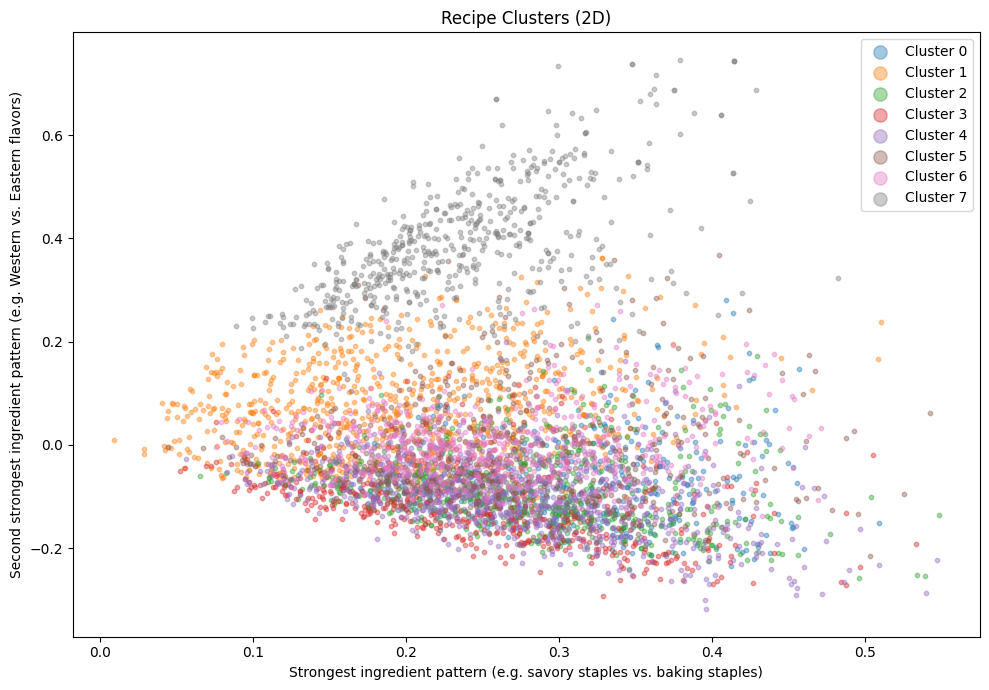

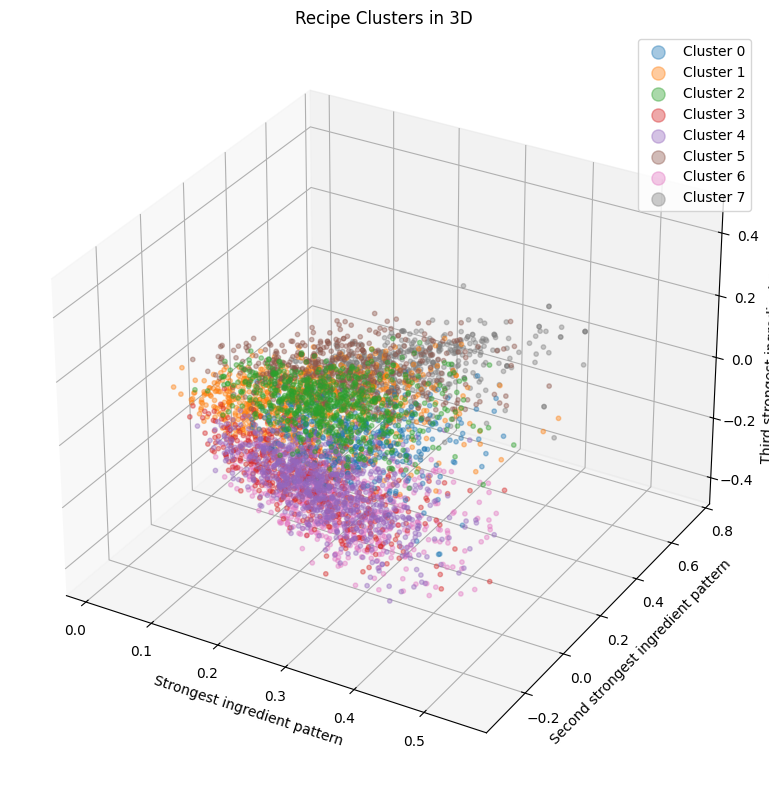

In [22]:
# TODO: TruncatedSVD to reduce the dimensions of our feature space
svd_2d = TruncatedSVD(n_components=2, random_state=42)
recipes_2d = svd_2d.fit_transform(recipes_vct)

svd_3d = TruncatedSVD(n_components=3, random_state=42)
recipes_3d = svd_3d.fit_transform(recipes_vct)

colors = cm.tab10(range(NUM_CLUSTERS))

# TODO: plot clusters in 2D
fig, ax = plt.subplots(figsize=(10, 7))
for i in range(NUM_CLUSTERS):
    mask = recipe_clusters == i
    ax.scatter(recipes_2d[mask, 0], recipes_2d[mask, 1],
               color=colors[i], alpha=0.4, s=10, label=f"Cluster {i}")

ax.legend(markerscale=3)
ax.set_title("Recipe Clusters (2D)")
ax.set_xlabel("Strongest ingredient pattern (e.g. savory staples vs. baking staples)")
ax.set_ylabel("Second strongest ingredient pattern (e.g. Western vs. Eastern flavors)")
plt.tight_layout()
plt.show()

# Plot clusters in 3D
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
for i in range(NUM_CLUSTERS):
    mask = recipe_clusters == i
    ax.scatter(recipes_3d[mask, 0], recipes_3d[mask, 1], recipes_3d[mask, 2],
               color=colors[i], alpha=0.4, s=10, label=f"Cluster {i}")

ax.legend(markerscale=3)
ax.set_title("Recipe Clusters in 3D")
ax.set_xlabel("Strongest ingredient pattern")
ax.set_ylabel("Second strongest ingredient pattern")
ax.set_zlabel("Third strongest ingredient pattern")
plt.tight_layout()
plt.show()

### Interpretation

What does the graph look like? Are the clusters well-separated?

<span style="color:hotpink">
Honestly? It's kind of a blob. The clusters are not cleanly separated. They bleed into each other a lot, especially in the middle. A few clusters (like Cluster 7, the baking one) seem to pull away a little, but mostly everything is squished together. I wouldn't call that a complete flop, though. The clustering happened in 520 dimensions. So there's a lot of space for groups to be well-separated there. When I compress all of that down to just 2 or 3 dimensions, I'm throwing away most of the information, so of course the separation looks messier. It's like trying to describe a 3D sculpture with just a shadow. I end up losing a lot. So the clusters are probably better-defined than the graph suggests. I'm hoping the silhouette plots will give me a cleaner read?
<span>

### Plot Silhouette Plots

We can also check the quality of our clustering by looking at the silhouette plots that we get from calling:<br>
`display_silhouette_plots(vectors, clusters)`.

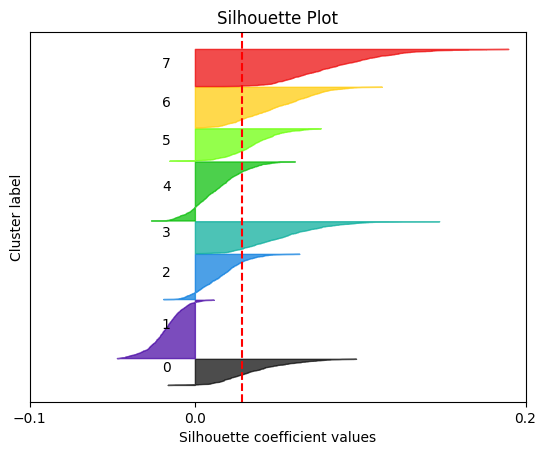

In [23]:
display_silhouette_plots(recipes_vct, recipe_clusters)

### Interpretation

How many clusters did you end up with? How do they look?

<span style="color:hotpink">
So I went with 8 clusters. And honestly... it's okay but not amazing lol. The average silhouette score (which is that red dashed line) is sitting around 0.07 something, which is low. It means a lot of recipes are ambiguous, like they could belong to more than one cluster. But some clusters are clearly holding their own. Cluster 7 (baking) has that big rightward spike. That meas those recipes know exactly where they belong, which makes total sense to me because baked goods have a very distinct ingredient fingerprint. Cluster 3 (Tex-Mex) is also doing pretty well. The messy ones (0, 1, 2) are the savory clusters that probably share too many ingredients with each other (I'm thinking Mediterranean vs. Italian vs. general comfort food). Those cuisines all have garlic, olive oil and salt. So maybe 5 or 6 clusters would've been cleaner. But hey, you live and you learn.
</span>

## Recipe Completion

Ok. On to the main event.

Let's create some recipes.

We'll do this using a technique similar to what is used for movie/product recommendations. Given an initial set of ingredients, we'll look at recipes that have similar ingredients and "recommend" additional ingredients.

We already have all of the recipes in our dataset encoded as `tf-idf` vectors. The rest of our algorithm will be something like:
1. Start with an initial set of ingredients
2. Encode ingredients
3. Find a set of recipes that are similar to our list of ingredients
4. Find common ingredients that are in the similar recipes, but not in our list of ingredients
5. Pick representative ingredient to add to recipe
6. Repeat

Let's start.

### 1. Initial list of ingredients

This is just a string with ingredients:

In [36]:
recipe_seed_str = "eggplant" # feel free to change this

### 2. Encode ingredients

Transform the string into a `tf-idf` vector using the `transofrm()` function from the pre-fitted `TfidfVectorizer` object:

In [37]:
# TODO: transform string into sparse vector
recipe_seed_vct = TFIDF.transform([recipe_seed_str])

print(f"Seed: '{recipe_seed_str}'")
print(f"Vector shape: {recipe_seed_vct.shape}")
print(f"Non-zero ingredients: {recipe_seed_vct.nnz}")

Seed: 'eggplant'
Vector shape: (1, 520)
Non-zero ingredients: 1


### 3. Find similar recipes

The meat of the algorithm. No pun intended.

In order to find similar recipes, we'll first calculate the distance between our current list of ingredients and all recipes in our dataset.

We can start with euclidean distance and later try other kinds, but the overall processing will be the same:

1. Start with an empty list to store distances
2. Loop over the `tf-idf` recipe vectors and for each vector:
   1. Subtract the ingredient list
   2. Square the difference (to square a sparse matrix `A`, use `A.multiply(A)`)
   3. Sum the terms of the result
   4. Take the square root of the sum
   5. Append to distance list
3. Find the indices of the smallest distances (this operation is called `argsort` and will give us the indices of the recipes that are most similar to our list of ingredients)
4. Check the recipes to see if they are indeed similar (`inverse_transform()` the vectors at the indices calculated above)

In [38]:
# argsort a list (get sequence of indices that would sort the list)
# https://stackoverflow.com/a/3382369
def argsort(L, reverse=False):
  L = L[0] if len(L) == 1 else L
  return sorted(range(len(L)), key=L.__getitem__, reverse=reverse)

In [39]:
# TODO: list to keep distances
recipe_distances = []

# TODO: loop over vectors and append euclidean distances to list
for i in range(recipes_vct.shape[0]):
    diff = recipes_vct[i] - recipe_seed_vct
    dist = diff.multiply(diff).sum() ** 0.5
    recipe_distances.append(dist)

# TODO: argsort list of distances to find indices of similar recipes
similar_idxs = argsort(recipe_distances)

# TODO: check first 4 recipes
print("4 most similar recipes to:", recipe_seed_str)
for idx in similar_idxs[:4]:
    print(f"  {TFIDF.inverse_transform(recipes_vct[idx])}")

4 most similar recipes to: eggplant
  [array(['salt', 'olive_oil', 'vinegar', 'garlic', 'red_pepper', 'oregano',
       'eggplant'], dtype='<U27')]
  [array(['egg', 'flour', 'salt', 'vegetable_oil', 'white_pepper', 'pepper',
       'eggplant'], dtype='<U27')]
  [array(['olive_oil', 'wine', 'tomatoes', 'oregano', 'eggplant',
       'feta_cheese'], dtype='<U27')]
  [array(['olive_oil', 'wine', 'tomatoes', 'oregano', 'eggplant',
       'feta_cheese'], dtype='<U27')]


### 4. Find ingredients to recommend

We have a way to get a set of similar recipes with similar ingredients, and now want to find a *meaningful*, or *representative*, ingredient to add to our ingredients list.

Let's consider ingredients in the $16$ most similar recipes. What we are trying to do is find an ingredient that is in a lot of these recipes, but not yet in our list of ingredients.

There are many possible ways of doing this. We could count the number of times different ingredients show up in these $16$ recipes using Python dictionaries and/or sets, but what we're trying to do here is very similar to what a `TfidfVectorizer` does: calculate relative importance of terms in a series of documents.

Let's re-encode these $16$ recipes using their own separate `TfidfVectorizer`, then sum the importance of each ingredient and look at ingredients with the highest importance scores.

We could re-use the vectors/scores from the original `TfidfVectorizer`, but they're gonna be influenced by the relative frequencies of all of the ingredients that showed up in all of the recipes. Using a separate vectorizer is a little bit more precise.

The steps we need to take are:

1. Separate the $16$ recipes most similar to our list of ingredients
   1. We have lots of representations of our recipes, but `recipes` (list of strings) might be the easiest one to use here
2. Create a new `TfidfVectorizer` and encode the $16$ recipes
3. Sum the resulting vectors by column to get overall importance scores for each ingredient/token
4. Convert resulting vector to a list using `A.tolist()[0]`
5. `argsort` the importance scores to get sequence of ingredient indices ordered from most to least important
6. Find the most important ingredient that isn't on the ingredient list

In [40]:
# TODO: Get 16 most similar recipes
similar_16 = [recipes[idx] for idx in similar_idxs[:16]]

# TODO: Encode the 16 recipes
TFIDF_local = TfidfVectorizer()
similar_16_vct = TFIDF_local.fit_transform(similar_16)
local_vocab = TFIDF_local.get_feature_names_out()

# TODO: Sum the recipe vectors by column to get ingredient importance scores
importance_scores = similar_16_vct.sum(axis=0)

# TODO: Convert sparse vector to regular list with A.tolist()[0]
importance_list = importance_scores.tolist()[0]

# TODO: argsort the importance scores
importance_idxs = argsort(importance_list, reverse=True)

# TODO: Find most important ingredient not yet on the list of ingredients
current_ingredients = set(recipe_seed_str.split())

for idx in importance_idxs:
    candidate = local_vocab[idx]
    if candidate not in current_ingredients:
        next_ingredient = candidate
        print(f"Recommended next ingredient: {next_ingredient}")
        break

Recommended next ingredient: olive_oil


### 5. Add ingredient to recipe

This is simply adding a word to `recipe_seed_str`

In [41]:
# TODO: add the first important ingredient to list of ingredients
recipe_seed_str = recipe_seed_str + " " + next_ingredient
print(f"Recipe so far: {recipe_seed_str}")

Recipe so far: eggplant olive_oil


### 6. Repeat (Optional)

Now we can repeat this process until we get an empty list of important ingredients: 
1. Encode current recipe
2. Find similar recipes
3. Find important ingredients
4. Add important ingredient

Might be helpful to define a couple of functions, like `find_similar_recipes()` and `find_important_ingredients()`...

Only do this step if you're really curious about experimenting with generating unconventional ingredient lists. It's not going to be graded.

In [42]:
# TODO: Create find_similar_recipes(ingredients, recipes, vectorizer)
def find_similar_recipes(ingredients, recipes, vectorizer, n=16):
    seed_vct = vectorizer.transform([ingredients])
    distances = []
    for i in range(recipes_vct.shape[0]):
        diff = recipes_vct[i] - seed_vct
        distances.append(diff.multiply(diff).sum() ** 0.5)
    top_idxs = argsort(distances)[:n]
    return [recipes[idx] for idx in top_idxs]

# TODO: Create find_important_ingredients(recipes)
def find_important_ingredients(similar_recipes, current_ingredients):
    local_tfidf = TfidfVectorizer()
    vcts = local_tfidf.fit_transform(similar_recipes)
    local_vocab = local_tfidf.get_feature_names_out()
    scores = vcts.sum(axis=0).tolist()[0]
    ranked = argsort(scores, reverse=True)
    current = set(current_ingredients.split())
    for idx in ranked:
        candidate = local_vocab[idx]
        if candidate not in current:
            return candidate
    return None

# TODO: Create recipe by repeating calls to find_similar_recipes() and find_important_ingredients()
recipe_seed_str = "eggplant"  # reset to start fresh
MAX_INGREDIENTS = 10

print(f"Starting with: {recipe_seed_str}")
for _ in range(MAX_INGREDIENTS - 1):
    similar = find_similar_recipes(recipe_seed_str, recipes, TFIDF)
    next_ing = find_important_ingredients(similar, recipe_seed_str)
    if next_ing is None:
        break
    recipe_seed_str += " " + next_ing
    print(f"  + {next_ing} -> {recipe_seed_str}")

Starting with: eggplant
  + olive_oil -> eggplant olive_oil
  + tomatoes -> eggplant olive_oil tomatoes
  + garlic -> eggplant olive_oil tomatoes garlic
  + salt -> eggplant olive_oil tomatoes garlic salt
  + onion -> eggplant olive_oil tomatoes garlic salt onion
  + oregano -> eggplant olive_oil tomatoes garlic salt onion oregano
  + basil -> eggplant olive_oil tomatoes garlic salt onion oregano basil
  + pepper -> eggplant olive_oil tomatoes garlic salt onion oregano basil pepper
  + wine -> eggplant olive_oil tomatoes garlic salt onion oregano basil pepper wine


<span style="color:hotpink">
Looks like we're somewhere in the Mediterranean
<span>

## Extra because I'd rather do this than work on my thesis

I want to visualise the trajectory of the recipe "finding itself" towards a cluster each time it adds an ingredient. I'm borrowing this idea from Raegan et al.'s appendix PDF.

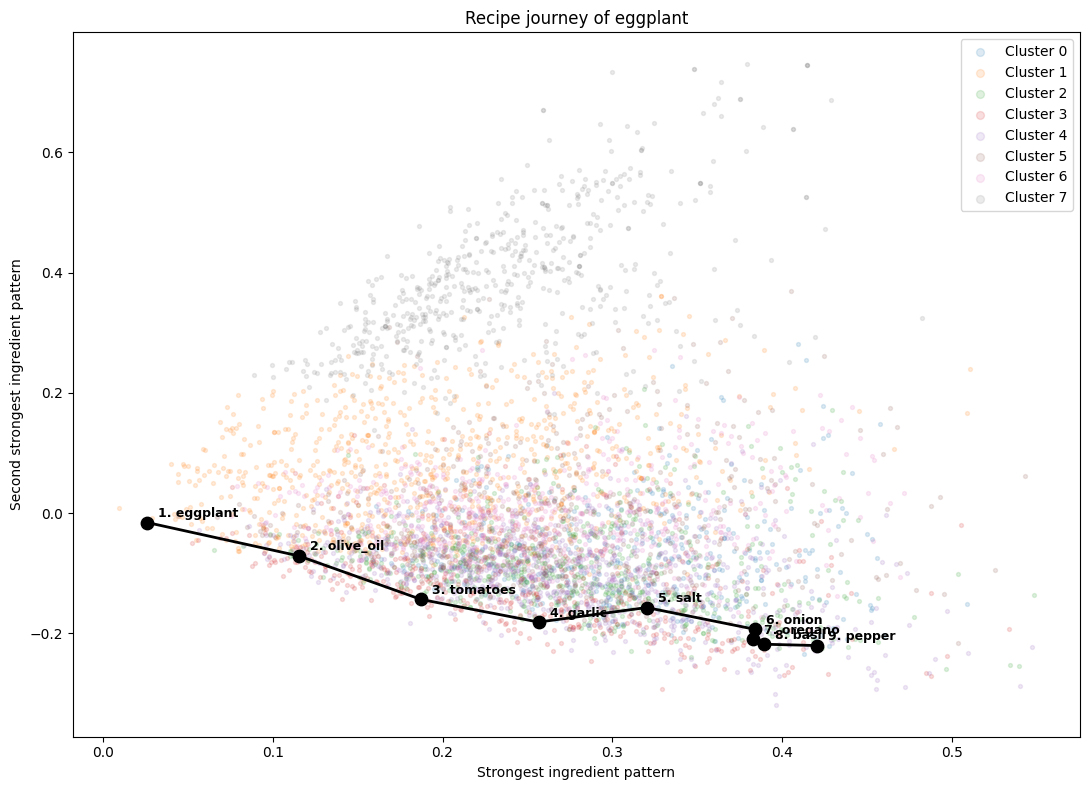

In [44]:
# Build the recipe step by step and record the vector position at each step
seed = "eggplant"
journey_points = []
journey_labels = []

current = seed
for _ in range(9):
    vct = TFIDF.transform([current])
    point = svd_2d.transform(vct.toarray())[0]
    journey_points.append(point)
    journey_labels.append(current.split()[-1])

    similar = find_similar_recipes(current, recipes, TFIDF)
    next_ing = find_important_ingredients(similar, current)
    if next_ing is None:
        break
    current += " " + next_ing

journey_points = np.array(journey_points)

# Plot the background cluster scatter
fig, ax = plt.subplots(figsize=(11, 8))
for i in range(NUM_CLUSTERS):
    mask = recipe_clusters == i
    ax.scatter(recipes_2d[mask, 0], recipes_2d[mask, 1],
               color=colors[i], alpha=0.15, s=8, label=f"Cluster {i}")

# Plot the journey trajectory
ax.plot(journey_points[:, 0], journey_points[:, 1],
        color="black", linewidth=2, zorder=3)
ax.scatter(journey_points[:, 0], journey_points[:, 1],
           color="black", s=80, zorder=4)

# Label each step
for i, (point, label) in enumerate(zip(journey_points, journey_labels)):
    ax.annotate(f"{i+1}. {label}", point,
                textcoords="offset points", xytext=(8, 4),
                fontsize=9, fontweight="bold")

ax.legend(markerscale=2, loc="upper right")
ax.set_title("Recipe journey of eggplant")
ax.set_xlabel("Strongest ingredient pattern")
ax.set_ylabel("Second strongest ingredient pattern")
plt.tight_layout()
plt.show()

<span style="color:hotpink">
That's suuuuuch a clean result. Eggplant starts isolated on the left (unknown territory, only 1 ingredient), then each addition pulls it rightward and downward into the dense savory cluster region. By step 6-9 it's barely moving, which means it's "settled" which means the recipe found its home and is just filling in details within that same neighborhood. The fact that it converges and stops drifting is the model telling me "yeah, this is Mediterranean, and I'm confident about it now."
<span style="color:hotpink">